In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [23]:
# dataset sintético
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: torch.Size([800, 20])
Forma de y_train: torch.Size([800, 1])
Forma de X_test: torch.Size([200, 20])
Forma de y_test: torch.Size([200, 1])


In [40]:
class SimplesNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimplesNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # Camada oculta
        self.relu = nn.ReLU()  # Ativação ReLU
        self.fc2 = nn.Linear(hidden_size, output_size)  # Camada de saída
        self.sigmoid = nn.Sigmoid()  # Ativação sigmoid para classificação binária

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out


input_size = 20  
hidden_size = 10 
output_size = 1  

model = SimplesNN(input_size, hidden_size, output_size)

In [41]:
criterion = nn.BCELoss()  
optimizer = optim.Adam(model.parameters(), lr=0.01) 

Época [1/10], Perda: 0.6845
Época [2/10], Perda: 0.6726
Época [3/10], Perda: 0.6608
Época [4/10], Perda: 0.6489
Época [5/10], Perda: 0.6366
Época [6/10], Perda: 0.6237
Época [7/10], Perda: 0.6103
Época [8/10], Perda: 0.5964
Época [9/10], Perda: 0.5823
Época [10/10], Perda: 0.5678


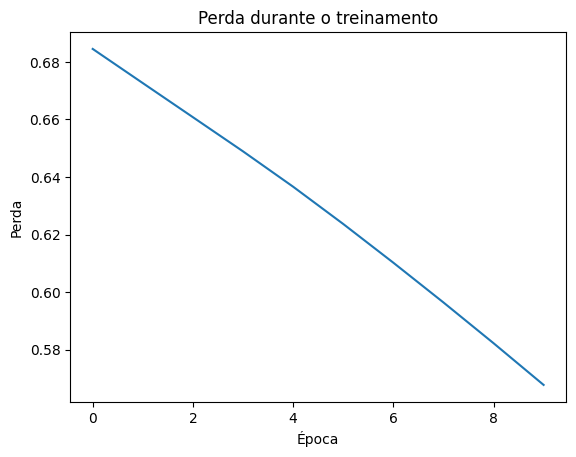

In [42]:
num_epochs = 10  # Número de épocas
losses = []  # Para armazenar as perdas

for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward pass e otimização
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    print(f"Época [{epoch+1}/{num_epochs}], Perda: {loss.item():.4f}")

# Plotar a perda ao longo das épocas
plt.plot(losses)
plt.xlabel("Época")
plt.ylabel("Perda")
plt.title("Perda durante o treinamento")
plt.show()

In [43]:
# Salvar os pesos do modelo
torch.save(model.state_dict(), "model_weights.pth")
print("Pesos do modelo salvos em '../models/model_weights.pth'")

Pesos do modelo salvos em '../models/model_weights.pth'


In [39]:

loaded_model = SimplesNN(input_size, hidden_size, output_size)

loaded_model.load_state_dict(torch.load("model_weights.pth"))

loaded_model.eval()
with torch.no_grad():
    outputs = loaded_model(X_test)
    predicted = (outputs > 0.5).float()  
    accuracy = (predicted == y_test).float().mean()
    print(f"Acurácia no teste: {accuracy.item() * 100:.2f}%")

Acurácia no teste: 84.50%


In [32]:

pesos_carregados = torch.load("model_weights.pth")
print("Conteúdo do arquivo model_weights.pth:")
print(pesos_carregados)

Conteúdo do arquivo model_weights.pth:
OrderedDict({'fc1.weight': tensor([[ 0.0614,  0.0280,  0.0302, -0.1581,  0.0623,  0.3080, -0.1945,  0.0444,
         -0.1653, -0.1706,  0.2068,  0.3611,  0.0483,  0.1013, -0.2017, -0.0837,
         -0.1907,  0.0299, -0.0076, -0.0952],
        [ 0.0369, -0.0986,  0.0201,  0.0082,  0.0347,  0.1819,  0.0435, -0.0895,
          0.0164,  0.0243, -0.0137,  0.2100, -0.0917,  0.0599, -0.1399,  0.0169,
         -0.1229, -0.0348, -0.2522,  0.0463],
        [ 0.0405, -0.1732, -0.0176, -0.0060, -0.0526,  0.2905, -0.0098, -0.0183,
         -0.0548,  0.0308,  0.0784,  0.0789, -0.0696,  0.0396, -0.0860,  0.0144,
         -0.0325, -0.0264, -0.2859, -0.0301],
        [ 0.2641,  0.2344, -0.2612, -0.2127,  0.2458,  0.0004,  0.1830, -0.1543,
          0.1334, -0.0728, -0.1818, -0.2436,  0.2781,  0.2232, -0.0196,  0.0904,
          0.2946,  0.0177,  0.2479, -0.3042],
        [ 0.1276,  0.0413, -0.0437,  0.1310,  0.2968,  0.2209,  0.0266, -0.2086,
          0.0449, -0.